In [1]:
import os
from qiskit import QuantumCircuit
import sinter

from src.stabilizer_code import extract, to_qiskit, surface_code
from src.simulate import tostim

from lib.TrapSIMD.sabre_iontrap import *
from lib.TrapSIMD.grid_iontrap import *

In [2]:
path = "./QEC-Code"

In [3]:
def gen_noise_profile(base=10 ** (-4)):
    p_trans = 2 * base 
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        "2q-gate": 18.3 * base
    }
    return noise_profile 

In [4]:
def gen_noise_profile2(p_trans = 2 * 10 ** (-4)):
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        "2q-gate": 18.3 * 10 ** (-4)
    }
    return noise_profile 

In [5]:
noise_list = [2 * 10 ** (-4) / k for k in range(1, 10, 2)]
d_list = [3, 5, 7, 9]
tasks = []

D = 5
L = 3
CZ = 3
draw_flag = False

for d in d_list:
    code_name = "surface-code"
    stab_fname = os.path.join(path, f"{code_name}-{d}.stab")
    surface_code(stab_fname, d)

    qasm_fname = os.path.join(path, f"{code_name}-{d}.qasm")
    is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)
    to_qiskit(qasm_fname, is_CSS, is_ordered, stabilizers, dataNum, iter=d*3)

    circ = QuantumCircuit.from_qasm_file(qasm_fname)
    num_q = circ.num_qubits
    num_s = circ.num_clbits

    result_our_list, node_list = grid_compiler(D, L, CZ, circ, draw_flag)

    for p in noise_list:
        circ = tostim(gen_noise_profile2(p), stabilizers, logicals, node_list, num_q, num_s)
        tasks.append(
            sinter.Task(circuit = circ, json_metadata={'d': d, 'r': d * 3, 'p': p})
    )

stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=1_000_000, #100_000_000,
    print_progress=True,
)

Starting 4 workers...
20 tasks left:
  workers    decoder eta shots_left errors_seen json_metadata                    
        1 pymatching   ?    1000000           0 d=3,r=9,p=0.0002                 
        1 pymatching <1m     980271         106 d=3,r=9,p=6.666666666666667e-05  
        1 pymatching   ?    1000000           0 d=3,r=9,p=4e-05                  
        1 pymatching   ?    1000000           0 d=3,r=9,p=2.8571428571428574e-05 
        0 pymatching ?·∞    1000000           0 d=3,r=9,p=2.2222222222222223e-05 
        0 pymatching ?·∞    1000000           0 d=5,r=15,p=0.0002                
        0 pymatching ?·∞    1000000           0 d=5,r=15,p=6.666666666666667e-05 
        0 pymatching ?·∞    1000000           0 d=5,r=15,p=4e-05                 
        0 pymatching ?·∞    1000000           0 d=5,r=15,p=2.8571428571428574e-05
        0 pymatching ?·∞    1000000           0 d=5,r=15,p=2.2222222222222223e-05
        0 pymatching ?·∞    1000000           0 d=7,r=21,p=0.

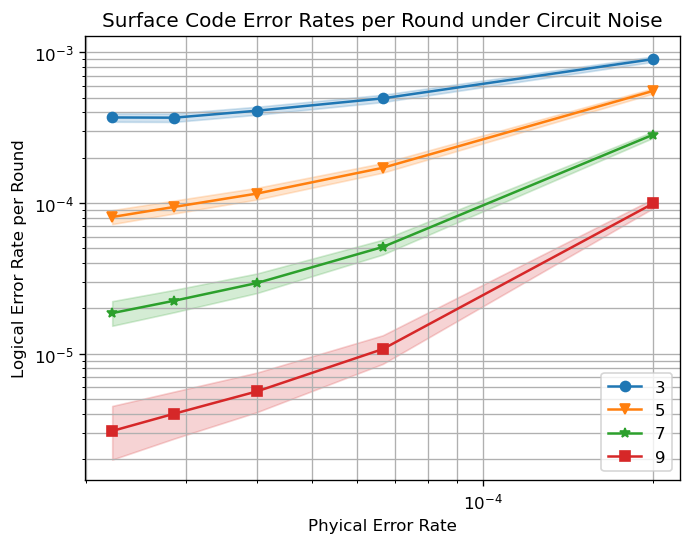

In [6]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
    failure_units_per_shot_func=lambda stats: stats.json_metadata['r'],
)
ax.loglog()
ax.set_title("Surface Code Error Rates per Round under Circuit Noise")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Round")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  